数据量： 6551
SVD特征维度： (6551, 50)

开始寻找最佳聚类数...
K=2, Silhouette=0.0426
K=3, Silhouette=0.0447
K=4, Silhouette=0.0540
K=5, Silhouette=0.0574
K=6, Silhouette=0.0656
K=7, Silhouette=0.0657
K=8, Silhouette=0.0743
K=9, Silhouette=0.0781
K=10, Silhouette=0.0820


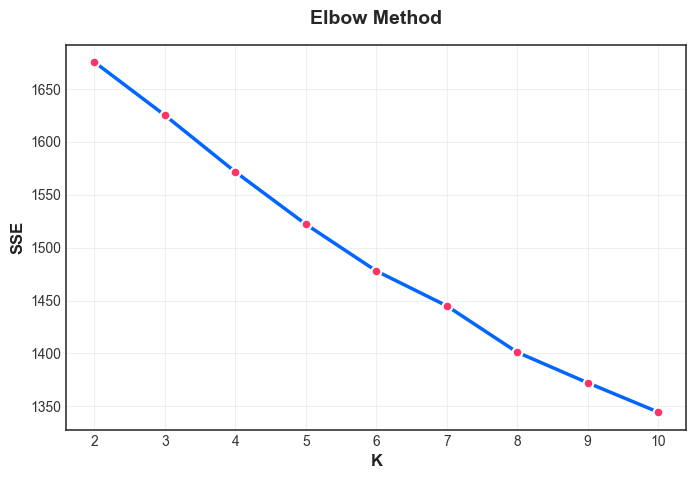

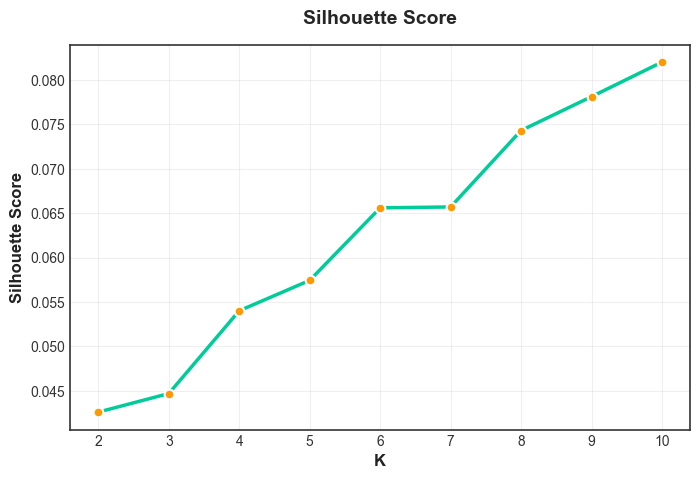


开始KMeans聚类，K=4

各聚类数量：
cluster
2    3165
0    2532
1     674
3     180
Name: count, dtype: int64

开始t-SNE可视化...


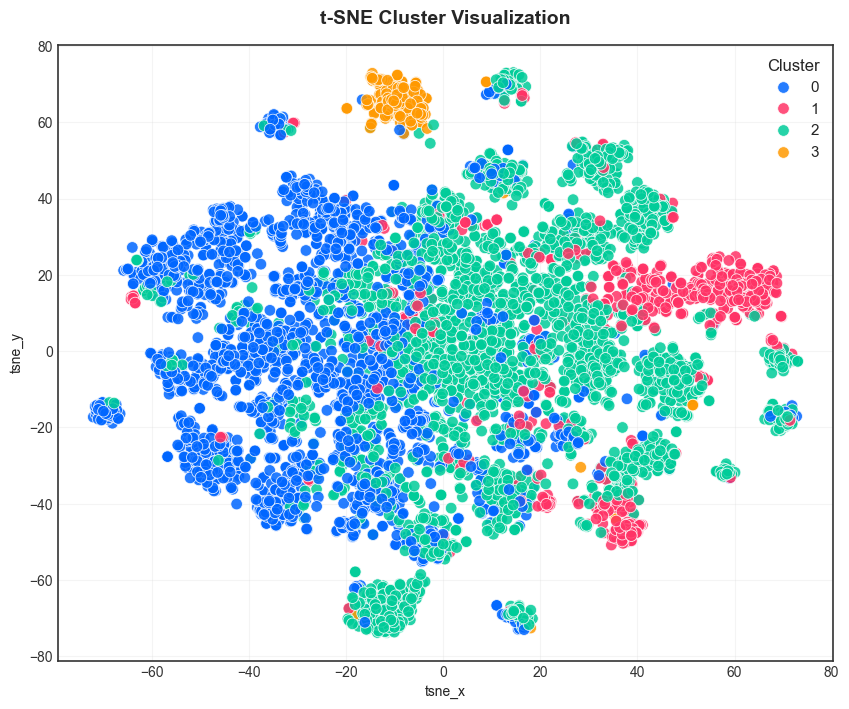


开始提取聚类关键词...

Cluster 0 关键词
['ability' 'abstract' 'according' 'accuracy' 'acid' 'academic' 'adhd'
 'alteration' 'affect' 'affected' 'active' 'activity' 'adolescent' 'acute'
 'aggression']

Cluster 1 关键词
['ability' 'abnormality' 'accuracy' 'abstract' 'achievement' 'abuse'
 'activation' 'activity' 'action' 'addiction' 'adhd' 'additionally'
 'adverse' 'addressing' 'amphetamine']

Cluster 2 关键词
['ability' 'abnormality' 'academic' 'access' 'action' 'acute' 'additional'
 'acid' 'adjustment' 'al' 'analyze' 'aged' 'active' 'affecting' 'affected']

Cluster 3 关键词
['access' 'abuse' 'ability' 'academic' 'abstract' 'accuracy' 'achievement'
 'acid' 'adaptive' 'addiction' 'adjustment' 'address' 'additional' 'aim'
 'adolescence']

开始层次聚类分析...


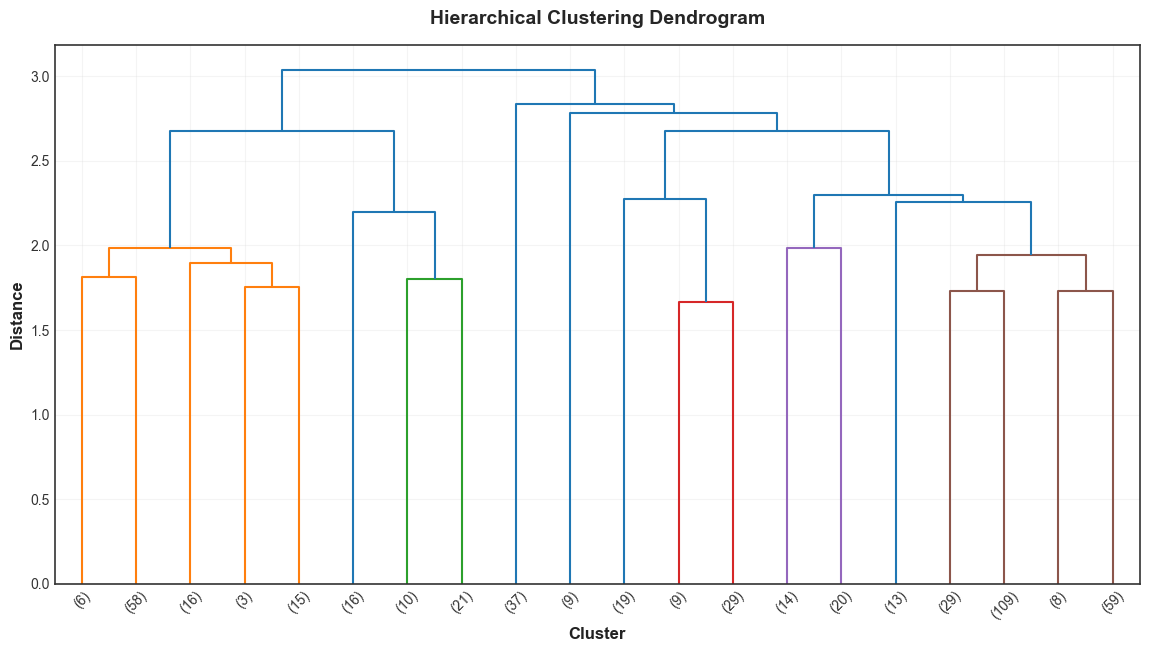


聚类统计结果：
         cited_by_count  authors_count  countries_count  publication_year
cluster                                                                  
0              2.588863      -0.151124        -0.069554       2024.103081
1              4.197329       0.416556         0.407191       2024.149852
2              2.802528       0.027576        -0.036853       2024.153239
3              2.988889       0.081156         0.101684       2024.200000

热点聚类分析完成！

结果文件：ADHD_热点聚类结果.csv


In [3]:
# ADHD研究热点挖掘
# 一、导入库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import linkage, dendrogram

# 二、读取数据
df = pd.read_csv("ADHD_特征工程后数据.csv")
X_svd = pd.read_csv("ADHD_SVD文本特征.csv")

print("数据量：", len(df))
print("SVD特征维度：", X_svd.shape)

# 三、寻找最佳K值（关键）
print("\n开始寻找最佳聚类数...")

sse = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_svd)

    # SSE
    sse.append(kmeans.inertia_)

    # 轮廓系数
    score = silhouette_score(X_svd, labels)
    silhouette_scores.append(score)

    print(f"K={k}, Silhouette={score:.4f}")

# 四、肘部图
plt.style.use('seaborn-v0_8-white')
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['axes.labelcolor'] = '#222222'
plt.rcParams['xtick.color'] = '#333333'
plt.rcParams['ytick.color'] = '#333333'
plt.figure(figsize=(8, 5))
plt.plot(K_range, sse, marker="o", color='#0066FF', linewidth=2.5, markersize=7, markerfacecolor='#FF3366', markeredgecolor='white', markeredgewidth=1.5)
plt.xlabel("K", fontsize=12, fontweight='bold')
plt.ylabel("SSE", fontsize=12, fontweight='bold')
plt.title("Elbow Method", fontsize=14, fontweight='bold', pad=15)
plt.grid(alpha=0.3, color='#CCCCCC')
plt.savefig("肘部图.png", dpi=300, bbox_inches='tight')
plt.show()

# 五、轮廓系数图
plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker="o", color='#00CC99', linewidth=2.5, markersize=7, markerfacecolor='#FF9900', markeredgecolor='white', markeredgewidth=1.5)
plt.xlabel("K", fontsize=12, fontweight='bold')
plt.ylabel("Silhouette Score", fontsize=12, fontweight='bold')
plt.title("Silhouette Score", fontsize=14, fontweight='bold', pad=15)
plt.grid(alpha=0.3, color='#CCCCCC')
plt.savefig("轮廓系数图.png", dpi=300, bbox_inches='tight')
plt.show()

# 六、正式KMeans聚类
# 根据轮廓系数修改
best_k = 4
print(f"\n开始KMeans聚类，K={best_k}")

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_svd)

# 七、聚类数量统计
cluster_counts = df["cluster"].value_counts()
print("\n各聚类数量：")
print(cluster_counts)

# 八、t-SNE降维可视化（核心）
print("\n开始t-SNE可视化...")

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_svd)

# 保存坐标
df["tsne_x"] = X_tsne[:, 0]
df["tsne_y"] = X_tsne[:, 1]

# t-SNE聚类图
plt.figure(figsize=(10, 8))
sns.scatterplot(x="tsne_x", y="tsne_y", hue="cluster", palette=['#0066FF', '#FF3366', '#00CC99', '#FF9900'], data=df, s=70, alpha=0.85, edgecolor='white', linewidth=0.6)
plt.title("t-SNE Cluster Visualization", fontsize=14, fontweight='bold', pad=15)
plt.legend(title="Cluster", title_fontsize=12, fontsize=11)
plt.grid(alpha=0.2, color='#CCCCCC')
plt.savefig("t-SNE聚类图.png", dpi=300, bbox_inches='tight')
plt.show()

# 九、聚类关键词提取（重要）
print("\n开始提取聚类关键词...")

from sklearn.feature_extraction.text import TfidfVectorizer

# 重新向量化
tfidf = TfidfVectorizer(max_features=1000, stop_words="english")
X_tfidf = tfidf.fit_transform(df["text_for_cluster"])
terms = np.array(tfidf.get_feature_names_out())

# 聚类中心
centroids = kmeans.cluster_centers_

# 输出每个聚类TOP关键词
for i in range(best_k):
    print("\n" + "="*50)
    print(f"Cluster {i} 关键词")
    print("="*50)
    center = centroids[i]
    top_indices = center.argsort()[-15:][::-1]
    top_words = terms[top_indices]
    print(top_words)

# 十、层次聚类（深度分析）
print("\n开始层次聚类分析...")

# 为避免计算量过大
sample_data = X_svd.sample(n=500, random_state=42)

# linkage
linked = linkage(sample_data, method="ward")

# 树状图
plt.figure(figsize=(14, 7))
dendrogram(
    linked,
    truncate_mode="lastp",
    p=20,
    leaf_rotation=45,
    leaf_font_size=10
)
plt.title("Hierarchical Clustering Dendrogram", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Cluster", fontsize=12, fontweight='bold')
plt.ylabel("Distance", fontsize=12, fontweight='bold')
plt.grid(alpha=0.2, color='#CCCCCC')
plt.savefig("树状图.png", dpi=300, bbox_inches='tight')
plt.show()

# 十一、聚类结果统计
cluster_summary = df.groupby("cluster").agg({
    "cited_by_count": "mean",
    "authors_count": "mean",
    "countries_count": "mean",
    "publication_year": "mean"
})

print("\n聚类统计结果：")
print(cluster_summary)

# 十二、保存结果
df.to_csv("ADHD_热点聚类结果.csv", index=False, encoding="utf-8-sig")

print("\n热点聚类分析完成！")
print("\n结果文件：ADHD_热点聚类结果.csv")